# PINN pro 2D lineární elastostatiku na kruhové oblasti

Cílem je aproximovat posunutí
$\mathbf u=(u_1,u_2)$ na kruhové oblasti o poloměru $R$:

$$
\Omega
=
\left\{
(x,y)\in\mathbb R^2:
x^2+y^2<R^2
\right\}.
$$

Přesné řešení je

$$
\mathbf u(x,y)
=
a
\begin{bmatrix}
x^2-y^2\\
2xy
\end{bmatrix}.
$$

Použité parametry jsou

$$

R=2
\qquad
a=0,15.
\qquad 
E=1,00,
\qquad
\nu=\frac14,
\qquad
\lambda=\mu=\frac25.
$$

## Silná forma

Stejná jako v `PINN_elastostatika_2D.ipynb`.


## Parametrizace kruhové hranice

Kružnici o poloměru $R$ se středem v počátku parametrizujeme
pomocí úhlu $\alpha$:

$$
\mathbf x(\alpha)
=
\begin{bmatrix}
x(\alpha)\\
y(\alpha)
\end{bmatrix}
=
\begin{bmatrix}
R\cos\alpha\\
R\sin\alpha
\end{bmatrix},
\qquad
\alpha\in[0,2\pi).
$$




Vnější jednotková normála kružnice je

$$
\mathbf n(\alpha)
=
\frac{1}{R}
\begin{bmatrix}
x(\alpha)\\
y(\alpha)
\end{bmatrix}
=
\begin{bmatrix}
\cos\alpha\\
\sin\alpha
\end{bmatrix}.
$$



## Smíšené okrajové podmínky

Hranici rozdělíme na horní Dirichletovu a dolní Neumannovu
půlkružnici:

$$
\Gamma_D
=
\left\{
(R\cos\alpha,R\sin\alpha):
\alpha\in[0,\pi]
\right\},
$$

$$
\Gamma_N
=
\left\{
(R\cos\alpha,R\sin\alpha):
\alpha\in(\pi,2\pi)
\right\}.
$$

### Dirichletova podmínka

Na $\Gamma_D$ předepisujeme přesné posunutí:

$$
\mathbf u(R\cos\alpha,R\sin\alpha)
=
a
\begin{bmatrix}
(R\cos\alpha)^2-(R\sin\alpha)^2\\
2(R\cos\alpha)(R\sin\alpha)
\end{bmatrix}.
$$

Po vytknutí $R^2$ dostaneme

$$
\mathbf u(R\cos\alpha,R\sin\alpha)
=
aR^2
\begin{bmatrix}
\cos^2\alpha-\sin^2\alpha\\
2\cos\alpha\sin\alpha
\end{bmatrix}.
$$

Pomocí goniometrických vztahů lze podmínku zapsat jako

$$
\boxed{
\mathbf u(R\cos\alpha,R\sin\alpha)
=
aR^2
\begin{bmatrix}
\cos(2\alpha)\\
\sin(2\alpha)
\end{bmatrix},
\qquad
\alpha\in[0,\pi].
}
$$

### Neumannova podmínka

Na $\Gamma_N$ předepisujeme trakci

$$
\boldsymbol{\sigma}\mathbf n=\mathbf t.
$$

Na kružnici dosadíme

$$
x=R\cos\alpha,
\qquad
y=R\sin\alpha.
$$

Tenzor napětí na kružnici je proto

$$
\boldsymbol{\sigma}(R\cos\alpha,R\sin\alpha)
=
4a(\lambda+\mu)R\cos\alpha\,\mathbf I.
$$

Trakce je

$$
\begin{aligned}
\mathbf t(R\cos\alpha,R\sin\alpha)
&=
\boldsymbol{\sigma}(R\cos\alpha,R\sin\alpha)
\mathbf n(\alpha)
\\
&=
4a(\lambda+\mu)R\cos\alpha\,
\mathbf I
\begin{bmatrix}
\cos\alpha\\
\sin\alpha
\end{bmatrix}.
\end{aligned}
$$

Po vynásobení dostaneme

$$
\boxed{
\mathbf t(R\cos\alpha,R\sin\alpha)
=
4a(\lambda+\mu)R
\begin{bmatrix}
\cos^2\alpha\\
\cos\alpha\sin\alpha
\end{bmatrix},
\qquad
\alpha\in(\pi,2\pi).
}
$$


## 1. Import knihoven

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


## 2. Nastavení parametrů

- `USE_DATA = True`: k fyzikální a okrajové loss se přidají známé hodnoty posunutí.
- `USE_DATA = False`: čistá PINN bez supervizovaných dat.
- Oblastí je kruh o poloměru `RADIUS = 1.0`.
- Posledních 100 epoch používá L-BFGS, předchozí epochy Adam.


In [37]:
USE_DATA = False
E = 1.0
NU = 1.0 / 4.0
LAMBDA = 2.0 / 5.0
MU = 2.0 / 5.0
AMPLITUDE = 0.15 
RADIUS = 2.0

N_PDE_TRAIN = 2000
N_PDE_TEST = 2000
N_BOUNDARY_PER_ARC = 100

N_DATA_TRAIN = 200
N_DATA_TEST = 200

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)

E_FROM_LAME = MU * (3.0 * LAMBDA + 2.0 * MU) / (LAMBDA + MU)
NU_FROM_LAME = LAMBDA / (2.0 * (LAMBDA + MU))

print(f"E z Lameho konstant:  {E_FROM_LAME:.6f}")
print(f"nu z Lameho konstant: {NU_FROM_LAME:.6f}")


E z Lameho konstant:  1.000000
nu z Lameho konstant: 0.250000


## 3. Přesné řešení, napětí a objemová síla

In [38]:
def exact_solution(xy):
    """Presne vektorove posunuti [u1, u2]."""
    x = xy[:, 0:1]
    y = xy[:, 1:2]

    u1 = AMPLITUDE * (x**2 - y**2)
    u2 = 2.0 * AMPLITUDE * x * y

    return torch.cat((u1, u2), dim=1)


def body_force(xy):
    """b = -div(sigma) pro zvolene presne reseni."""
    b1 = -4.0 * AMPLITUDE * (LAMBDA + MU) * torch.ones_like(xy[:, 0:1])
    b2 = torch.zeros_like(xy[:, 1:2])

    return torch.cat((b1, b2), dim=1)


def exact_stress(xy):
    """Presne slozky sigma_xx, sigma_yy, sigma_xy."""
    x = xy[:, 0:1]

    normal_stress = 4.0 * AMPLITUDE * (LAMBDA + MU) * x
    shear_stress = torch.zeros_like(x)

    return normal_stress, normal_stress, shear_stress


def exact_traction(xy, normals):
    """Presna trakce t = sigma*n."""
    sigma_xx, sigma_yy, sigma_xy = exact_stress(xy)

    nx = normals[:, 0:1]
    ny = normals[:, 1:2]

    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny

    return torch.cat((traction_x, traction_y), dim=1)


## 4. Neuronová síť

In [39]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 2),
        )

    def forward(self, xy):
        return self.net(xy)


model = PINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Trénovací, testovací a okrajové body

- `xy_pde_train`: vnitřní kolokační body rovnoměrně vzorkované v ploše disku a použité ve fyzikální loss.
- `xy_pde_test`: jiné body uvnitř disku, použité pouze při závěrečném testování.
- `xy_dirichlet`: body na horní půlkružnici $\alpha\in[0,\pi]$ se známým posunutím.
- `xy_neumann`: body uvnitř dolního oblouku $\alpha\in(\pi,2\pi)$ se známou trakcí.
- Krajní body $(\pm1,0)$ patří pouze do Dirichletovy množiny, aby se okrajové množiny nepřekrývaly.

Pro rovnoměrné vzorkování plochy kruhu používáme

$$
r=R\sqrt{\xi},\qquad \alpha=2\pi\eta,
$$



In [40]:
def sample_points_in_disk(n_points, generator):
    """Rovnomerne vzorkuje body v plose disku."""
    random_radius = torch.rand(n_points, 1, generator=generator)
    random_angle = torch.rand(n_points, 1, generator=generator)

    radius = RADIUS * torch.sqrt(random_radius)
    angle = 2.0 * torch.pi * random_angle

    x = radius * torch.cos(angle)
    y = radius * torch.sin(angle)
    return torch.cat((x, y), dim=1)


pde_train_generator = torch.Generator().manual_seed(SEED + 1)
xy_pde_train = sample_points_in_disk(
    N_PDE_TRAIN,
    pde_train_generator,
)
xy_pde_train.requires_grad_(True)

pde_test_generator = torch.Generator().manual_seed(SEED + 2)
xy_pde_test = sample_points_in_disk(
    N_PDE_TEST,
    pde_test_generator,
)
xy_pde_test.requires_grad_(True)


# Dirichletova podminka na horni pulkruznici, vcetne krajnich bodu.
alpha_dirichlet = torch.linspace(
    0.0,
    torch.pi,
    N_BOUNDARY_PER_ARC,
).view(-1, 1)

xy_dirichlet = RADIUS * torch.cat(
    (torch.cos(alpha_dirichlet), torch.sin(alpha_dirichlet)),
    dim=1,
)
u_dirichlet = exact_solution(xy_dirichlet)


# Neumannova podminka na dolni pulkruznici.
# Body jsou uprostred uhlu dilcich intervalu, proto nelezi v krajnich bodech.
boundary_index = torch.arange(
    N_BOUNDARY_PER_ARC,
    dtype=torch.get_default_dtype(),
).view(-1, 1)

alpha_neumann = torch.pi + (boundary_index + 0.5) * torch.pi / N_BOUNDARY_PER_ARC

xy_neumann = RADIUS * torch.cat(
    (torch.cos(alpha_neumann), torch.sin(alpha_neumann)),
    dim=1,
)

# Na kruznici o polomeru R je vnejsi jednotkova normala n = (x/R, y/R).
normals_neumann = xy_neumann / RADIUS

# Presnou trakci spocitame pred zapnutim derivovani vstupu.
traction_neumann = exact_traction(xy_neumann, normals_neumann).detach()

# Derivace posunuti jsou nutne pro vypocet sigma*n.
xy_neumann.requires_grad_(True)


if USE_DATA:
    data_train_generator = torch.Generator().manual_seed(SEED + 3)
    xy_data_train = sample_points_in_disk(
        N_DATA_TRAIN,
        data_train_generator,
    )
    u_data_train = exact_solution(xy_data_train)

    data_test_generator = torch.Generator().manual_seed(SEED + 4)
    xy_data_test = sample_points_in_disk(
        N_DATA_TEST,
        data_test_generator,
    )
    u_data_test = exact_solution(xy_data_test)


## 6. PDE reziduum a ztrátová funkce

Fyzikální reziduum PINN je definováno jako

$$
\mathbf{r}_{\theta}(x,y)
=
\nabla \cdot \boldsymbol{\sigma}(\mathbf{u}_{\theta})
+\mathbf{b}.
$$

PDE ztrátová funkce je

$$
\mathcal{L}_{\mathrm{PDE}}
=
\frac{1}{2N_c}
\sum_{i=1}^{N_c}
\left\|
\mathbf{r}_{\theta}(x_i,y_i)
\right\|_2^2.
$$

Celková ztrátová funkce je

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{PDE}}
+
\mathcal{L}_{\mathrm{D}}
+
\mathcal{L}_{\mathrm{N}}
+
\mathcal{L}_{\mathrm{data}}.
$$

Dirichletova loss na horní půlkružnici je

$$
\mathcal{L}_{\mathrm{D}}
=
\frac{1}{2N_D}
\sum_{i=1}^{N_D}
\left\|
\mathbf{u}_{\theta}(\cos\alpha_i,\sin\alpha_i)
-
a
\begin{bmatrix}
\cos(2\alpha_i)\\
\sin(2\alpha_i)
\end{bmatrix}
\right\|_2^2,
\qquad \alpha_i\in[0,\pi].
$$

Neumannova loss na dolní půlkružnici je

$$
\mathcal{L}_{\mathrm{N}}
=
\frac{1}{2N_N}
\sum_{i=1}^{N_N}
\left\|
\boldsymbol{\sigma}
\left(\mathbf{u}_{\theta}(\cos\alpha_i,\sin\alpha_i)\right)
\begin{bmatrix}
\cos\alpha_i\\
\sin\alpha_i
\end{bmatrix}
-
0.16
\begin{bmatrix}
\cos^2\alpha_i\\
\cos\alpha_i\sin\alpha_i
\end{bmatrix}
\right\|_2^2,
\qquad \alpha_i\in(\pi,2\pi).
$$

Pro `USE_DATA = False` platí

$$
\mathcal{L}_{\mathrm{data}}=0.
$$


In [41]:
def stress_components(xy):
    """Vrati sigma_xx, sigma_yy, sigma_xy pro predikci site."""
    u = model(xy)
    u1 = u[:, 0:1]
    u2 = u[:, 1:2]

    grad_u1 = torch.autograd.grad(
        u1,
        xy,
        grad_outputs=torch.ones_like(u1),
        create_graph=True,
        retain_graph=True,
    )[0]

    grad_u2 = torch.autograd.grad(
        u2,
        xy,
        grad_outputs=torch.ones_like(u2),
        create_graph=True,
        retain_graph=True,
    )[0]

    du1_dx = grad_u1[:, 0:1]
    du1_dy = grad_u1[:, 1:2]
    du2_dx = grad_u2[:, 0:1]
    du2_dy = grad_u2[:, 1:2]

    eps_xx = du1_dx
    eps_yy = du2_dy
    eps_xy = 0.5 * (du1_dy + du2_dx)
    trace_eps = eps_xx + eps_yy

    sigma_xx = LAMBDA * trace_eps + 2.0 * MU * eps_xx
    sigma_yy = LAMBDA * trace_eps + 2.0 * MU * eps_yy
    sigma_xy = 2.0 * MU * eps_xy

    return sigma_xx, sigma_yy, sigma_xy


def pde_residual(xy, training=True):
    """Vrati dve slozky rezidua div(sigma) + b."""
    sigma_xx, sigma_yy, sigma_xy = stress_components(xy)

    grad_sigma_xx = torch.autograd.grad(
        sigma_xx,
        xy,
        grad_outputs=torch.ones_like(sigma_xx),
        create_graph=training,
        retain_graph=True,
    )[0]

    grad_sigma_yy = torch.autograd.grad(
        sigma_yy,
        xy,
        grad_outputs=torch.ones_like(sigma_yy),
        create_graph=training,
        retain_graph=True,
    )[0]

    grad_sigma_xy = torch.autograd.grad(
        sigma_xy,
        xy,
        grad_outputs=torch.ones_like(sigma_xy),
        create_graph=training,
        retain_graph=True,
    )[0]

    b = body_force(xy)

    residual_1 = (
        grad_sigma_xx[:, 0:1]
        + grad_sigma_xy[:, 1:2]
        + b[:, 0:1]
    )

    residual_2 = (
        grad_sigma_xy[:, 0:1]
        + grad_sigma_yy[:, 1:2]
        + b[:, 1:2]
    )

    return torch.cat((residual_1, residual_2), dim=1)


def compute_losses():
    # PDE loss.
    residual = pde_residual(xy_pde_train, training=True)
    loss_pde = torch.mean(residual**2)

    # Dirichletova loss na horni pulkruznici.
    dirichlet_prediction = model(xy_dirichlet)
    loss_dirichlet = torch.mean(
        (dirichlet_prediction - u_dirichlet) ** 2
    )

    # Neumannova loss na dolni pulkruznici.
    sigma_xx, sigma_yy, sigma_xy = stress_components(xy_neumann)

    nx = normals_neumann[:, 0:1]
    ny = normals_neumann[:, 1:2]

    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny
    traction_prediction = torch.cat((traction_x, traction_y), dim=1)

    loss_neumann = torch.mean(
        (traction_prediction - traction_neumann) ** 2
    )

    loss_bc = loss_dirichlet + loss_neumann

    # Volitelna datova loss.
    if USE_DATA:
        data_prediction = model(xy_data_train)
        loss_data = torch.mean((data_prediction - u_data_train) ** 2)
    else:
        loss_data = torch.tensor(0.0)

    loss = loss_pde + loss_bc + loss_data

    return (
        loss,
        loss_pde,
        loss_bc,
        loss_data,
    )


## 7. Trénování: Adam a L-BFGS

Prvních $1900$ epoch používá Adam. Posledních 100 používá L-BFGS s funkcí closure.


In [42]:
loss_history = []
pde_loss_history = []
bc_loss_history = []
data_loss_history = []

ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_adam,
    mode="min",
    factor=0.5,
    patience=200,
)
# 1) Adam
for epoch in range(ADAM_EPOCHS):
    optimizer_adam.zero_grad()
    xy_pde_train.grad = None
    xy_neumann.grad = None

    loss, loss_pde, loss_bc, loss_data = compute_losses()
    loss.backward()
    optimizer_adam.step()
    scheduler.step(loss.item())
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())

    if epoch % 500 == 0:
        print(
            f"Adam  | epocha {epoch:5d} | loss = {loss.item():.6e} | "
            f"PDE = {loss_pde.item():.6e} | "
            f"BC = {loss_bc.item():.6e} | "
            f"data = {loss_data.item():.6e}"
        )


# 2) L-BFGS
print(f"Prepinam z Adam na L-BFGS v epose {ADAM_EPOCHS}.")

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe",
)

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        xy_pde_train.grad = None
        xy_neumann.grad = None

        loss, _, _, _ = compute_losses()
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)

    loss, loss_pde, loss_bc, loss_data = compute_losses()

    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(
            f"L-BFGS | epocha {epoch:5d} | loss = {loss.item():.6e} | "
            f"PDE = {loss_pde.item():.6e} | "
            f"BC = {loss_bc.item():.6e} | "
            f"data = {loss_data.item():.6e}"
        )

model.eval()


Adam  | epocha     0 | loss = 5.597479e-01 | PDE = 1.145249e-01 | BC = 4.452229e-01 | data = 0.000000e+00
Adam  | epocha   500 | loss = 9.086997e-04 | PDE = 4.203675e-04 | BC = 4.883322e-04 | data = 0.000000e+00
Adam  | epocha  1000 | loss = 1.333456e-04 | PDE = 1.111158e-04 | BC = 2.222973e-05 | data = 0.000000e+00
Adam  | epocha  1500 | loss = 1.015573e-04 | PDE = 5.695701e-05 | BC = 4.460027e-05 | data = 0.000000e+00
Prepinam z Adam na L-BFGS v epose 1900.
L-BFGS | epocha  1900 | loss = 2.749538e-05 | PDE = 2.043783e-05 | BC = 7.057557e-06 | data = 0.000000e+00
L-BFGS | epocha  1950 | loss = 1.025341e-06 | PDE = 8.949708e-07 | BC = 1.303702e-07 | data = 0.000000e+00
L-BFGS | epocha  1999 | loss = 1.025341e-06 | PDE = 8.949708e-07 | BC = 1.303702e-07 | data = 0.000000e+00


PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): Tanh()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): Tanh()
    (10): Linear(in_features=20, out_features=2, bias=True)
  )
)

## 8. Testování na nezávislých kolokačních bodech

Na bodech `xy_pde_test`, které leží uvnitř disku a nebyly použity při trénování, počítáme:

- $R^2$ skóre pro obě složky posunutí,
- relativní $L^2$ chybu posunutí,
- MSE obou složek PDE rezidua.


In [43]:
model.eval()
xy_pde_test.grad = None

residual_test = pde_residual(xy_pde_test, training=False)
pde_test_mse = torch.mean(residual_test**2).detach().item()

with torch.no_grad():
    u_test_prediction = model(xy_pde_test)
    u_test_exact = exact_solution(xy_pde_test)

    ss_res = torch.sum((u_test_prediction - u_test_exact) ** 2)
    ss_tot = torch.sum((u_test_exact - torch.mean(u_test_exact)) ** 2)
    r2_test = (1.0 - ss_res / ss_tot).item()

    relative_l2_test = (
        torch.linalg.vector_norm(u_test_prediction - u_test_exact)
        / torch.linalg.vector_norm(u_test_exact)
    ).item()

metrics = {
    "R2_collocation_test": r2_test,
    "relative_L2_collocation_test": relative_l2_test,
    "PDE_test_MSE": pde_test_mse,
}

print("=" * 60)
print("TESTOVACI VYSLEDKY 2D PINN NA JEDNOTKOVEM DISKU")
print("=" * 60)
print(f"R2 na kolokacnich testovacich bodech: {r2_test:.8f}")
print(f"Relativni L2 chyba:                    {relative_l2_test:.6e}")
print(f"MSE PDE rezidua:                       {pde_test_mse:.6e}")
print("=" * 60)

metrics


TESTOVACI VYSLEDKY 2D PINN NA JEDNOTKOVEM DISKU
R2 na kolokacnich testovacich bodech: 0.99999672
Relativni L2 chyba:                    1.817339e-03
MSE PDE rezidua:                       9.516110e-07


{'R2_collocation_test': 0.9999967217445374,
 'relative_L2_collocation_test': 0.0018173394491896033,
 'PDE_test_MSE': 9.516109571450215e-07}

## 9. Vizualizační funkce

In [44]:
def make_grid(n=81, requires_grad=False):
    values = torch.linspace(-RADIUS, RADIUS, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    mask = X**2 + Y**2 <= RADIUS**2

    if requires_grad:
        xy.requires_grad_(True)

    return X.numpy(), Y.numpy(), xy, mask.numpy()


def add_circle_outline(axis):
    outline = plt.Circle(
        (0.0, 0.0),
        RADIUS,
        fill=False,
        color="black",
        linewidth=1.0,
    )
    axis.add_patch(outline)


def plot_points():
    ncols = 2 if USE_DATA else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))

    if ncols == 1:
        axes = [axes]

    axes[0].scatter(
        xy_pde_test[:, 0].detach().numpy(),
        xy_pde_test[:, 1].detach().numpy(),
        s=8,
        alpha=0.25,
        label="PDE test",
    )
    axes[0].scatter(
        xy_pde_train[:, 0].detach().numpy(),
        xy_pde_train[:, 1].detach().numpy(),
        s=10,
        alpha=0.5,
        label="PDE train",
    )
    axes[0].scatter(
        xy_dirichlet[:, 0].detach().numpy(),
        xy_dirichlet[:, 1].detach().numpy(),
        s=14,
        color="tab:red",
        label="Dirichlet: horni oblouk",
    )
    axes[0].scatter(
        xy_neumann[:, 0].detach().numpy(),
        xy_neumann[:, 1].detach().numpy(),
        s=14,
        color="black",
        label="Neumann: dolni oblouk",
    )
    add_circle_outline(axes[0])
    axes[0].set_title("Fyzikalni a smisene okrajove body")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_xlim(-1.1 * RADIUS, 1.1 * RADIUS)
    axes[0].set_ylim(-1.1 * RADIUS, 1.1 * RADIUS)
    axes[0].set_aspect("equal")
    axes[0].legend()
    axes[0].grid()

    if USE_DATA:
        axes[1].scatter(
            xy_data_test[:, 0].numpy(),
            xy_data_test[:, 1].numpy(),
            s=12,
            alpha=0.4,
            label="data test",
        )
        axes[1].scatter(
            xy_data_train[:, 0].numpy(),
            xy_data_train[:, 1].numpy(),
            s=20,
            label="data train",
        )
        add_circle_outline(axes[1])
        axes[1].set_title("Supervizovana data")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")
        axes[1].set_xlim(-1.1 * RADIUS, 1.1 * RADIUS)
        axes[1].set_ylim(-1.1 * RADIUS, 1.1 * RADIUS)
        axes[1].set_aspect("equal")
        axes[1].legend()
        axes[1].grid()

    fig.tight_layout()
    plt.show()


def plot_displacement(n=301):
    X, Y, xy, mask = make_grid(n)

    with torch.no_grad():
        prediction = model(xy)
        exact = exact_solution(xy)
        error = torch.abs(prediction - exact)

    prediction = prediction.numpy().reshape(n, n, 2)
    exact = exact.numpy().reshape(n, n, 2)
    error = error.numpy().reshape(n, n, 2)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    for component in range(2):
        exact_masked = np.ma.masked_where(~mask, exact[:, :, component])
        prediction_masked = np.ma.masked_where(
            ~mask, prediction[:, :, component],
        )
        error_masked = np.ma.masked_where(~mask, error[:, :, component])

        limit = max(
            np.max(np.abs(exact_masked.compressed())),
            np.max(np.abs(prediction_masked.compressed())),
        )

        plots = [
            axes[component, 0].contourf(X,Y,exact_masked, levels=40, cmap="coolwarm", vmin=-limit, vmax=limit,),
            axes[component, 1].contourf(X,Y,prediction_masked,levels=40,cmap="coolwarm", vmin=-limit,vmax=limit,),
            axes[component, 2].contourf(X,Y,error_masked,levels=40,cmap="viridis",),]

        axes[component, 0].set_title(f"Presne u{component + 1}")
        axes[component, 1].set_title(f"PINN u{component + 1}")
        axes[component, 2].set_title(f"Absolutni chyba u{component + 1}")

        for axis, image in zip(axes[component], plots):
            add_circle_outline(axis)
            axis.set_xlabel("x")
            axis.set_ylabel("y")
            axis.set_aspect("equal")
            fig.colorbar(image, ax=axis)

    fig.tight_layout()
    plt.savefig("pinn_circle_displacement.pdf", bbox_inches="tight")
    plt.show()


def plot_deformed_domain(scale=1.0, n_circles=6, n_rays=12, n_points=181):
    fig, ax = plt.subplots(figsize=(8, 8))

    angle_values = torch.linspace(0.0, 2.0 * torch.pi, n_points)
    radius_values = torch.linspace(0.0, RADIUS, n_points)
    circle_radii = torch.linspace(
        RADIUS / n_circles,
        RADIUS,
        n_circles,
    )
    ray_angles = torch.arange(n_rays) * (2.0 * torch.pi / n_rays)

    lines = []

    for radius in circle_radii:
        circle = torch.stack(
            (
                radius * torch.cos(angle_values),
                radius * torch.sin(angle_values),
            ),
            dim=1,
        )
        lines.append(circle)

    for angle in ray_angles:
        ray = torch.stack(
            (
                radius_values * torch.cos(angle),
                radius_values * torch.sin(angle),
            ),
            dim=1,
        )
        lines.append(ray)

    first_line = True

    for line in lines:
        with torch.no_grad():
            exact_deformed = line + scale * exact_solution(line)
            pinn_deformed = line + scale * model(line)

        ax.plot(
            line[:, 0].numpy(),
            line[:, 1].numpy(),
            color="gray",
            linestyle=":",
            alpha=0.4,
            label="puvodni" if first_line else None,
        )
        ax.plot(
            exact_deformed[:, 0].numpy(),
            exact_deformed[:, 1].numpy(),
            "r--",
            alpha=0.8,
            label="presna deformace" if first_line else None,
        )
        ax.plot(
            pinn_deformed[:, 0].numpy(),
            pinn_deformed[:, 1].numpy(),
            color="tab:blue",
            alpha=0.8,
            label="PINN deformace" if first_line else None,
        )

        first_line = False

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Deformovana kruhova oblast, meritko posunuti = {scale}")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    #plt.savefig("pinn_circle_deformed2D.pdf", bbox_inches="tight")
    plt.show()


def plot_pde_residual(n=301):
    X, Y, xy, mask = make_grid(n, requires_grad=True)
    residual = pde_residual(xy, training=False).detach().numpy()
    residual = residual.reshape(n, n, 2)

    interior_values = residual[mask]
    limit = np.max(np.abs(interior_values))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for component in range(2):
        residual_masked = np.ma.masked_where(
            ~mask,
            residual[:, :, component],
        )
        image = axes[component].contourf(
            X,
            Y,
            residual_masked,
            levels=40,
            cmap="coolwarm",
            vmin=-limit,
            vmax=limit,
        )
        add_circle_outline(axes[component])
        axes[component].set_title(f"PDE reziduum r{component + 1}")
        axes[component].set_xlabel("x")
        axes[component].set_ylabel("y")
        axes[component].set_aspect("equal")
        fig.colorbar(image, ax=axes[component])

    fig.tight_layout()
    #plt.savefig("pinn_circle_residual2D.pdf", bbox_inches="tight")
    plt.show()


def plot_loss():
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(loss_history, label="celkova")
    ax.plot(pde_loss_history, label="PDE")
    ax.plot(bc_loss_history, label="okrajove podminky")

    if USE_DATA:
        ax.plot(data_loss_history, label="data")

    ax.axvline(
        ADAM_EPOCHS,
        color="black",
        linestyle=":",
        label="prechod na L-BFGS",
    )

    ax.set_yscale("log")
    ax.set_xlabel("epocha")
    ax.set_ylabel("loss")
    ax.legend()
    ax.grid()

    fig.tight_layout()
    #plt.savefig("pinn_circle_loss2D.pdf", bbox_inches="tight")
    plt.show()


## 10. Vizualizace

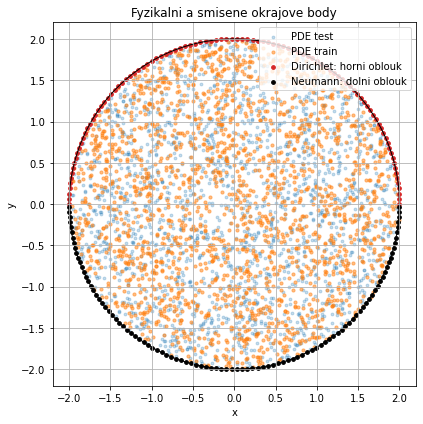

In [45]:
plot_points()


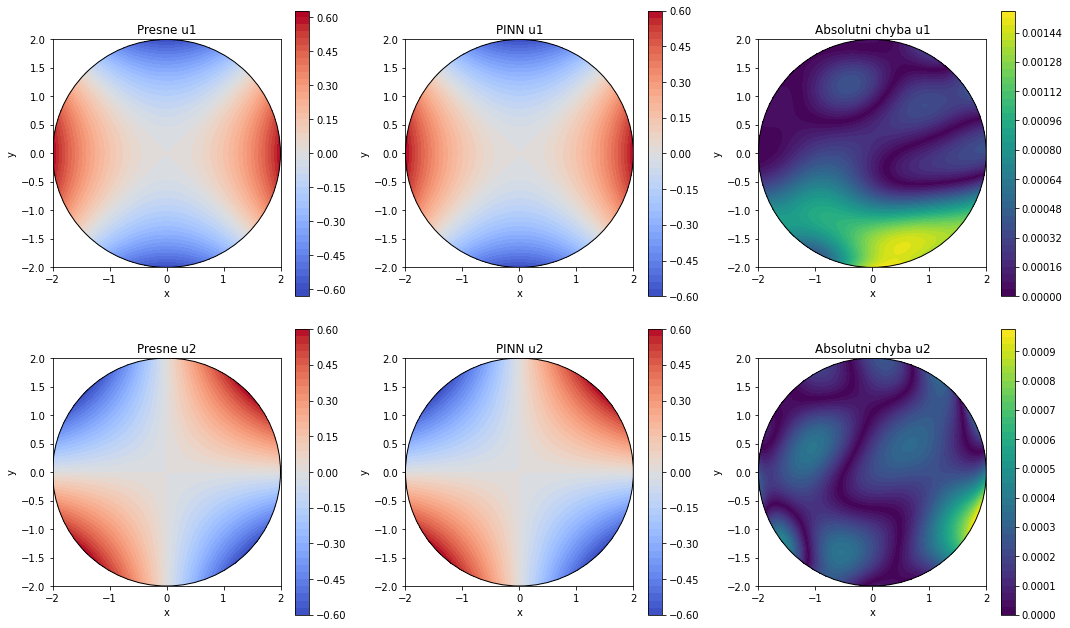

In [46]:
plot_displacement()


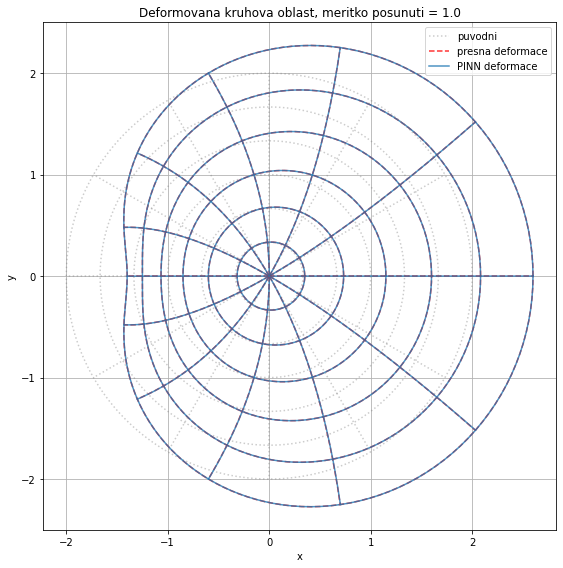

In [47]:
plot_deformed_domain(scale=1.0)


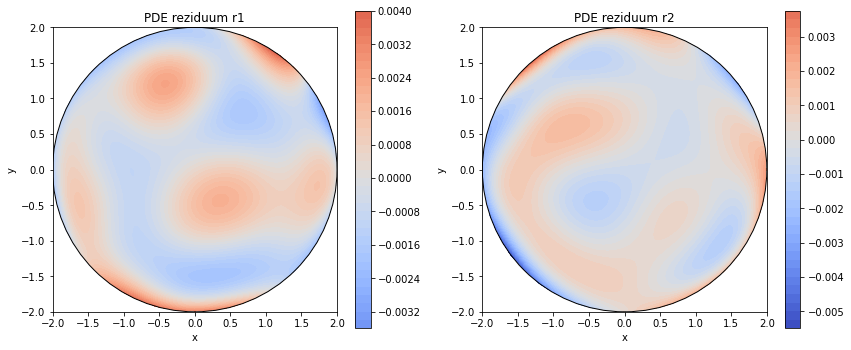

In [48]:
plot_pde_residual()


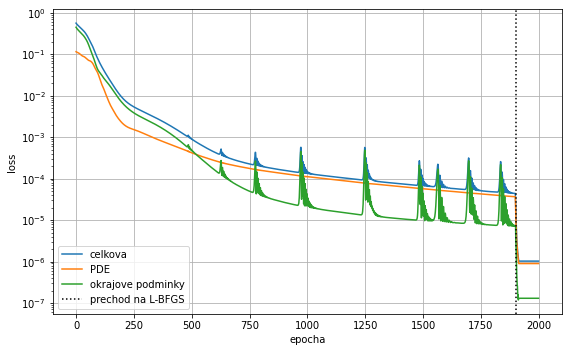

In [49]:
plot_loss()
